# MEEP MPI Scaling Benchmark

Runs the same simulation with `meep_np` = 1, 2, 4, 8, 16 in parallel on
GDSFactory+ cloud, then compares CUPS (cell updates per second).

The cloud Batch job allocates **8 vCPUs** (4 physical cores), 32GB RAM
(see `infra/iac/units/simulation-engine/job-definitions.tf`).
The entrypoint allows MPI oversubscription, so np=16 won't fail — it'll
just oversubscribe the 8 vCPUs.

**Requirements:**
- UBC PDK: `uv pip install ubcpdk`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

## 1. Configure simulation

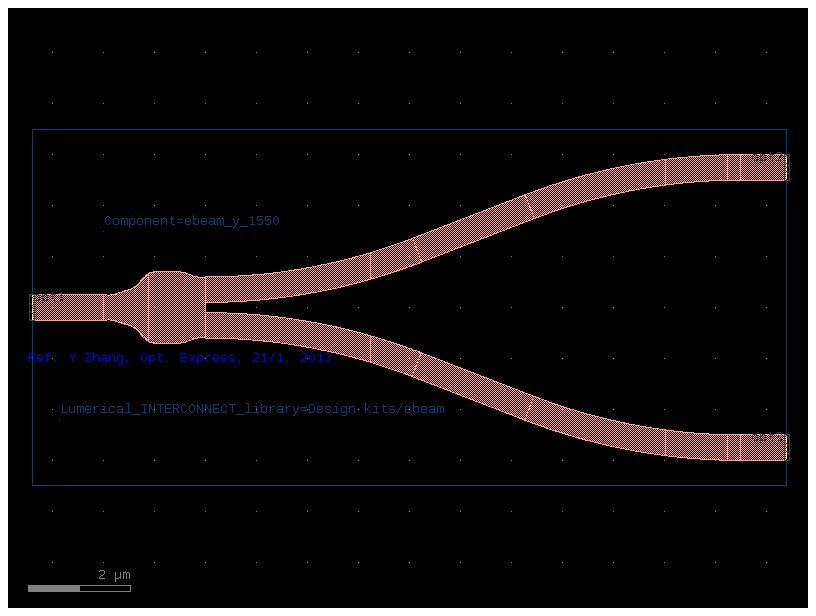

In [14]:
from ubcpdk import PDK, cells

PDK.activate()
c = cells.ebeam_y_1550()
c

In [15]:
from gsim import meep

sim = meep.Simulation()

sim.geometry(component=c, z_crop="auto")
sim.materials = {"si": 3.47, "SiO2": 1.44}
sim.source(port="o1", wavelength=1.55, wavelength_span=0.01, num_freqs=11)
sim.monitors = ["o1", "o2", "o3"]
sim.domain(pml=1.0, margin=0.5)
sim.solver(resolution=25, verbose_interval=5.0)
sim.solver.stop_after_sources(time=100)

print(sim.validate_config())

Stack validation: PASSED
Warnings:
  - No stack configured. Will use active PDK with defaults.


## 2. Create variants and submit all jobs

In [16]:
import json
import shutil
import tempfile
from pathlib import Path

from gsim import gcloud

np_values = [1, 2, 4, 8, 16]

# Write base config once
base_dir = Path(tempfile.mkdtemp(prefix="meep_bench_"))
sim.write_config(base_dir)

# Create variant per meep_np, upload and start
job_ids = {}  # meep_np -> job_id

for np_val in np_values:
    variant_dir = base_dir.parent / f"meep_bench_np{np_val}"
    if variant_dir.exists():
        shutil.rmtree(variant_dir)
    shutil.copytree(base_dir, variant_dir)

    # Patch meep_np in config
    cfg = json.loads((variant_dir / "sim_config.json").read_text())
    cfg["meep_np"] = np_val
    (variant_dir / "sim_config.json").write_text(json.dumps(cfg, indent=2))

    job_id = gcloud.upload(variant_dir, "meep")
    gcloud.start(job_id)
    job_ids[np_val] = job_id
    print(f"meep_np={np_val:>2}: {job_id}")

print(f"\nSubmitted {len(job_ids)} jobs")

Uploading simulation... done (job_id: 019d4f4f-a5fe-7c50-b9ce-8e5d9d41377a)
Job started: meep-a6294ecf
meep_np= 1: 019d4f4f-a5fe-7c50-b9ce-8e5d9d41377a
Uploading simulation... done (job_id: 019d4f4f-afdf-7c12-8ba9-123ad7b5cfe8)
Job started: meep-cb07964d
meep_np= 2: 019d4f4f-afdf-7c12-8ba9-123ad7b5cfe8
Uploading simulation... done (job_id: 019d4f4f-b9ec-7442-ad5a-45bc97a9adb6)
Job started: meep-27c3e6d3
meep_np= 4: 019d4f4f-b9ec-7442-ad5a-45bc97a9adb6
Uploading simulation... done (job_id: 019d4f4f-c33b-7810-bbc9-154179e6a7a3)
Job started: meep-715c1830
meep_np= 8: 019d4f4f-c33b-7810-bbc9-154179e6a7a3
Uploading simulation... done (job_id: 019d4f4f-cca3-7632-8e1f-a026d901ade9)
Job started: meep-0362c974
meep_np=16: 019d4f4f-cca3-7632-8e1f-a026d901ade9

Submitted 5 jobs


## 3. Wait for all jobs

In [17]:
import gsim

ordered_nps = list(job_ids.keys())
ordered_ids = list(job_ids.values())

results = gsim.wait_for_results(*ordered_ids, parent_dir=".")
if not isinstance(results, list):
    results = [results]

np_to_result = dict(zip(ordered_nps, results))
print(f"All {len(np_to_result)} jobs complete")

Waiting for 5 jobs...
  meep-a6294ecf                  completed    27m 28s
  meep-cb07964d                  completed    14m 56s
  meep-27c3e6d3                  completed    11m 12s
  meep-715c1830                  completed    8m 07s
  meep-0362c974                  completed    6m 26s
Extracting results.tar.gz...
Downloaded 6 files to sim-data-meep-a6294ecf
Extracting results.tar.gz...
Downloaded 6 files to sim-data-meep-cb07964d
Extracting results.tar.gz...
Downloaded 6 files to sim-data-meep-27c3e6d3
Extracting results.tar.gz...
Downloaded 6 files to sim-data-meep-715c1830
Extracting results.tar.gz...
Downloaded 6 files to sim-data-meep-0362c974
All 5 jobs complete


## 4. Compute CUPS and plot

In [18]:
benchmark = []

for np_val, result in np_to_result.items():
    meta = result.debug_info.get("metadata", {})
    if not meta:
        print(f"meep_np={np_val}: no metadata, skipping")
        continue

    cx, cy, cz = meta["cell_size"]
    res = meta["resolution"]
    nx, ny, nz = int(cx * res), int(cy * res), int(cz * res)
    total_cells = nx * ny * nz
    ts = meta["timesteps"]
    ws = meta["wall_seconds"]
    cups = (total_cells * ts) / ws

    benchmark.append(
        {
            "meep_np": np_val,
            "resolution": res,
            "grid": f"{nx}x{ny}x{nz}",
            "total_cells": total_cells,
            "timesteps": ts,
            "wall_seconds": ws,
            "cups": cups,
            "mcups": cups / 1e6,
        }
    )

benchmark.sort(key=lambda x: x["meep_np"])

print(f"{'NP':>4} {'Grid':>20} {'Cells':>12} {'Steps':>7} {'Wall(s)':>10} {'MCUPS':>8}")
print("-" * 70)
for b in benchmark:
    print(
        f"{b['meep_np']:>4} {b['grid']:>20} {b['total_cells']:>12,} {b['timesteps']:>7,} {b['wall_seconds']:>10.1f} {b['mcups']:>8.1f}"
    )

  NP                 Grid        Cells   Steps    Wall(s)    MCUPS
----------------------------------------------------------------------
   1           448x250x80    8,960,000   8,875     1280.6     62.1
   2           448x250x80    8,960,000   8,875      652.3    121.9
   4           448x250x80    8,960,000   8,875      417.5    190.5
   8           448x250x80    8,960,000   8,875      266.0    299.0
  16           448x250x80    8,960,000   8,875      168.7    471.4


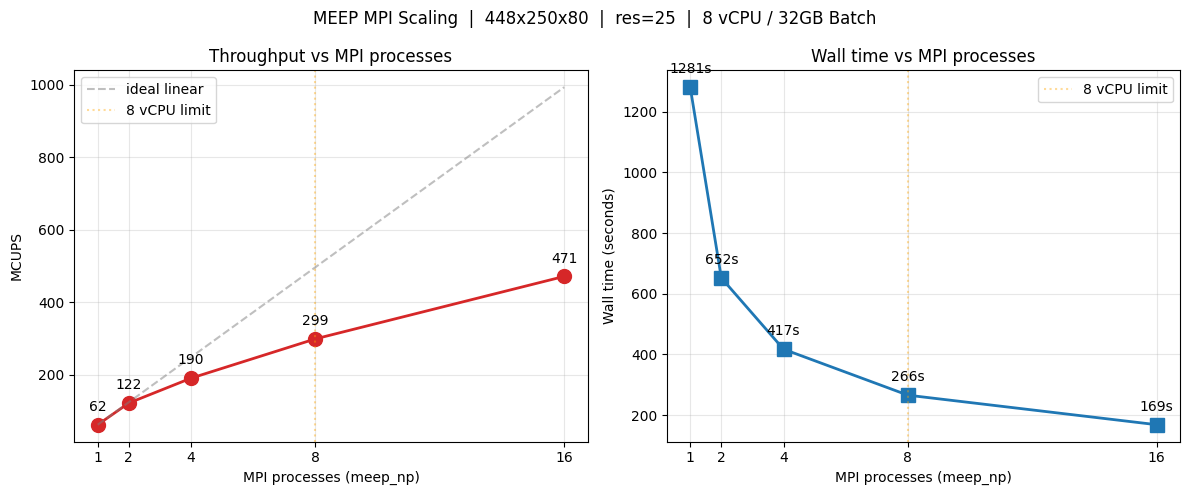

In [19]:
import matplotlib.pyplot as plt

nps = [b["meep_np"] for b in benchmark]
mcups = [b["mcups"] for b in benchmark]
wall_s = [b["wall_seconds"] for b in benchmark]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# MCUPS vs NP
ax1.plot(nps, mcups, "o-", color="tab:red", markersize=10, linewidth=2)
ax1.set_xlabel("MPI processes (meep_np)")
ax1.set_ylabel("MCUPS")
ax1.set_title("Throughput vs MPI processes")
ax1.set_xticks(nps)
ax1.grid(True, alpha=0.3)
for x, y in zip(nps, mcups):
    ax1.annotate(
        f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center"
    )

# Ideal scaling reference
ideal = [mcups[0] * n / nps[0] for n in nps]
ax1.plot(nps, ideal, "--", color="gray", alpha=0.5, label="ideal linear")
ax1.axvline(x=8, color="orange", alpha=0.4, linestyle=":", label="8 vCPU limit")
ax1.legend()

# Wall time vs NP
ax2.plot(nps, wall_s, "s-", color="tab:blue", markersize=10, linewidth=2)
ax2.set_xlabel("MPI processes (meep_np)")
ax2.set_ylabel("Wall time (seconds)")
ax2.set_title("Wall time vs MPI processes")
ax2.set_xticks(nps)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=8, color="orange", alpha=0.4, linestyle=":", label="8 vCPU limit")
for x, y in zip(nps, wall_s):
    ax2.annotate(
        f"{y:.0f}s", (x, y), textcoords="offset points", xytext=(0, 10), ha="center"
    )
ax2.legend()

plt.suptitle(
    f"MEEP MPI Scaling  |  {benchmark[0]['grid']}  |  res={benchmark[0]['resolution']}  |  8 vCPU / 32GB Batch",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Save benchmark data for later

In [20]:
# Save so we can reload without re-running cloud jobs
import json
from pathlib import Path

Path("benchmark_cups.json").write_text(json.dumps(benchmark, indent=2))
print(f"Saved {len(benchmark)} results to benchmark_cups.json")

Saved 5 results to benchmark_cups.json


---
## Load from disk (skip cells above)

In [21]:
import json
from pathlib import Path

benchmark = json.loads(Path("benchmark_cups.json").read_text())

print(f"{'NP':>4} {'Grid':>20} {'Cells':>12} {'Steps':>7} {'Wall(s)':>10} {'MCUPS':>8}")
print("-" * 70)
for b in benchmark:
    print(
        f"{b['meep_np']:>4} {b['grid']:>20} {b['total_cells']:>12,} {b['timesteps']:>7,} {b['wall_seconds']:>10.1f} {b['mcups']:>8.1f}"
    )

  NP                 Grid        Cells   Steps    Wall(s)    MCUPS
----------------------------------------------------------------------
   1           448x250x80    8,960,000   8,875     1280.6     62.1
   2           448x250x80    8,960,000   8,875      652.3    121.9
   4           448x250x80    8,960,000   8,875      417.5    190.5
   8           448x250x80    8,960,000   8,875      266.0    299.0
  16           448x250x80    8,960,000   8,875      168.7    471.4
